##### Plotly:
    Plotly is an open-source Python visualization library used to create interactive, attractive, and web-based graphs and charts.
    🔷 Features of Plotly
        Interactive graphs
        Zoom in / Zoom out
        Hover information
        Pan and select data
        3D plots support
        Dashboard creation
        Works with Pandas and NumPy

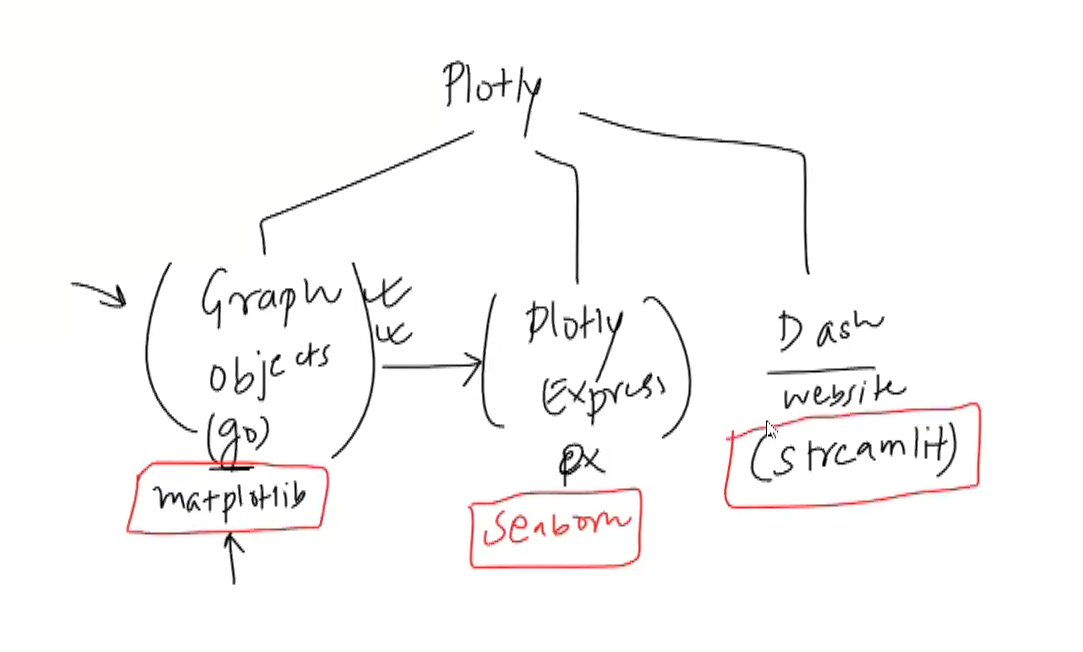

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

In [2]:
tips = px.data.tips()
iris = px.data.iris()
gap = px.data.gapminder()

In [3]:
gap.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [4]:
temp_df = gap[gap['year']==2007]
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32


In [5]:
# ploting lifeexp vs gdpPercp scatter plot using graph_object or GO

trace1 = go.Scatter(x=temp_df['lifeExp'],y=temp_df['gdpPercap'],mode='markers')
trace2 = go.Scatter(x=[0,1,2],y=[0,90,30000],mode='lines')
data = [trace1,trace2]
layout = go.Layout(title='LifeExp VS gdpPercap in 2007',xaxis={'title':'Life Exp'},yaxis={'title':'GDP'})
fig = go.Figure(data,layout)
fig.show()

In [6]:
# ploting life exp vs gdpPercp scatter plot using express or px ->continent as color ->pop as size,->hovar name,->rang_x/rang_y->log_x,log_y
px.scatter( temp_df,
           x=temp_df['lifeExp'],
           y=temp_df['gdpPercap'],
           color='continent',
           size='pop',
           size_max=100,
           hover_name='country')

    🔷 animation_frame
    ✅ Definition

        animation_frame batata hai ki animation kis column ke basis par chalegi.

        👉 Har unique value = ek frame
        👉 Us column ko do jo time ko represent kare:

    🔷 animation_group
    ✅ Definition

        animation_group ek object ki identity maintain karta hai across frames.
        Us column ko do jo unique entity ho:

In [7]:
# plot animation of the above graph on the basis of year
px.scatter(gap,
           x=gap['lifeExp'],y=gap['gdpPercap'],
           color='continent',
           size='pop',size_max=100,
           hover_name='country',
           animation_frame='year',animation_group='country',
           range_x=[30,95])


In [8]:
# Line plot
# plot india pop line plot over the years

temp_df = gap[gap['country']=='India']
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
696,India,Asia,1952,37.373,372000000,546.565749,IND,356
697,India,Asia,1957,40.249,409000000,590.061996,IND,356
698,India,Asia,1962,43.605,454000000,658.347151,IND,356
699,India,Asia,1967,47.193,506000000,700.770611,IND,356
700,India,Asia,1972,50.651,567000000,724.032527,IND,356


In [9]:
px.line(temp_df,x='year',y='pop',title='india pop over the years')   

In [10]:
# plot india china pak line plot of life Exp
temp_df = gap[gap['country'].isin(['India','Pakistan','China'])]
temp_df.head(2)

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
288,China,Asia,1952,44.00000,556263527,400.448611,CHN,156
289,China,Asia,1957,50.54896,637408000,575.987001,CHN,156


In [11]:
px.line(temp_df,x='year',y='lifeExp',color='country')

In [12]:
# bar chart 
# bar chart of india's pop over the year
temp_df = gap[gap['country']=='India']
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
696,India,Asia,1952,37.373,372000000,546.565749,IND,356
697,India,Asia,1957,40.249,409000000,590.061996,IND,356
698,India,Asia,1962,43.605,454000000,658.347151,IND,356
699,India,Asia,1967,47.193,506000000,700.770611,IND,356
700,India,Asia,1972,50.651,567000000,724.032527,IND,356


In [13]:
px.bar(temp_df,x='year',y='pop')

In [14]:
# plot india china pak line plot of pop
temp_df = gap[gap['country'].isin(['India','Pakistan','China'])]
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
288,China,Asia,1952,44.00000,556263527,400.448611,CHN,156
289,China,Asia,1957,50.54896,637408000,575.987001,CHN,156
290,China,Asia,1962,44.50136,665770000,487.674018,CHN,156
291,China,Asia,1967,58.38112,754550000,612.705693,CHN,156
292,China,Asia,1972,63.11888,862030000,676.900092,CHN,156


In [15]:
px.bar(temp_df,x='year',y='gdpPercap',color='country',barmode='group')

In [16]:
px.bar(temp_df,x='year',y='pop',color='country',barmode='group',log_y=True,text_auto=True)

In [18]:
# stacked bar chart
# pop contribution per country to a continents pop stacked for a particular year(2007)
temp_df = gap[gap['year']==2007]
px.bar(temp_df,x='continent',y='pop',color='country',log_y=True)

In [30]:
# bar chart animation
px.bar(gap,x='continent',y='pop',color='continent',animation_frame='year',animation_group='country',range_y=[0,4000000000])

In [33]:
# plot histogram of life exp of all countries in 2007 ->nbins ->text_auto
temp_df = gap[gap['year']==2007]
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32


In [40]:
px.histogram(temp_df,x='lifeExp',text_auto=True,nbins=20)

In [46]:
# plot histogram of sepal lenght of all iris species
px.histogram(iris,x='sepal_length',text_auto=True,nbins=10)

In [48]:
px.histogram(iris,x='sepal_length',color='species',text_auto=True,nbins=10)

In [61]:
# pie ->values->names
# find the pie chart of pop of european countries in 2007

temp_df = gap[(gap['year']==2007) & (gap['continent']=='Europe')]
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
83,Austria,Europe,2007,79.829,8199783,36126.492700,AUT,40
119,Belgium,Europe,2007,79.441,10392226,33692.605080,BEL,56
155,Bosnia and Herzegovina,Europe,2007,74.852,4552198,7446.298803,BIH,70
191,Bulgaria,Europe,2007,73.005,7322858,10680.792820,BGR,100


In [66]:
px.pie(temp_df,values='pop',names='country')

In [69]:
# plot pie chart of world pop in 1952 continent wise ->-> explod(pull)
temp_df = gap[gap['year']==1952]
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
12,Albania,Europe,1952,55.230,1282697,1601.056136,ALB,8
24,Algeria,Africa,1952,43.077,9279525,2449.008185,DZA,12
36,Angola,Africa,1952,30.015,4232095,3520.610273,AGO,24
48,Argentina,Americas,1952,62.485,17876956,5911.315053,ARG,32


In [77]:
px.pie(temp_df,values='pop',names='continent')

In [ ]:
# sunburst plot->sunburst plot visualize hierarchical data spanning outwards radially from root to leaves 
# ->colour->path ->values
temp_df = gap[gap['year']==2007]
px.sunburst(temp_df,path=['continent','country'],values='pop',color='lifeExp')

In [85]:
px.sunburst(tips,path=['sex','smoker','day','time'],values='total_bill',color='size')

In [90]:
# Treemap:
px.treemap(temp_df,path=[px.Constant('Wolrd'),'continent','country'],values='pop',color='lifeExp')

In [95]:
# Heatmap : find heat map of all continent with year on avg life exp
temp_df = gap.pivot_table(index='year',columns='continent',values='lifeExp',aggfunc='mean')
temp_df.head()

continent,Africa,Americas,Asia,Europe,Oceania
year,,,,,
1952,39.135500,53.27984,46.314394,64.408500,69.255
1957,41.266346,55.96028,49.318544,66.703067,70.295
1962,43.319442,58.39876,51.563223,68.539233,71.085
1967,45.334538,60.41092,54.663640,69.737600,71.310
1972,47.450942,62.39492,57.319269,70.775033,71.910


In [97]:
px.imshow(temp_df)

In [102]:
# 3D scatter plot:
# plot a 3d scatter plot of all countries for 2007 on lifeExp,gdp,pop
temp_df = gap[gap['year']==2007]
temp_df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
11,Afghanistan,Asia,2007,43.828,31889923,974.580338,AFG,4
23,Albania,Europe,2007,76.423,3600523,5937.029526,ALB,8
35,Algeria,Africa,2007,72.301,33333216,6223.367465,DZA,12
47,Angola,Africa,2007,42.731,12420476,4797.231267,AGO,24
59,Argentina,Americas,2007,75.320,40301927,12779.379640,ARG,32


In [110]:
px.scatter_3d(temp_df,x='lifeExp',y='pop',z='gdpPercap',color='continent',hover_name='country',log_y=True)

In [115]:
px.scatter_3d(iris,x='sepal_length',y='sepal_width',z='petal_length',color='species',hover_name='species')